In [1]:
# 1. Limpieza y clonación del repositorio
%cd /content
!rm -rf clasificacion-crecimiento-plantas
!git clone https://github.com/Karime8502/clasificacion-crecimiento-plantas.git

/content
Cloning into 'clasificacion-crecimiento-plantas'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 97 (delta 33), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 49.76 KiB | 16.58 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [2]:
# 2. Conectar a Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 3. Descargar el dataset (YOLO v8) directo desde Roboflow
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="8rW0BxoFomqTQk2oqss2")
project = rf.workspace("diego-agudelo").project("madurez_plantas")
version = project.version(1)
dataset = version.download("yolov8", location="/content/clasificacion-crecimiento-plantas/dataset")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/clasificacion-crecimiento-plantas/dataset in yolov8:: 100%|██████████| 1593/1593 [00:00<00:00, 8893.85it/s]


In [4]:
# 4. Entrenar modelo CNN
%cd /content/clasificacion-crecimiento-plantas/codigo
!python entrenar.py --modelo cnn --dataset_dir ../dataset --epocas 25

/content/clasificacion-crecimiento-plantas/codigo
2026-08-11 03:54:22.190919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Aviso: ../dataset/train/labels/IMG_20260808_152405_jpg.rf.8d24f83d88e7e88a3f46ee7c1532ab19.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_153123_jpg.rf.fed599ca63d56283c50b7ceb521b6fe6.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_154056_jpg.rf.a0c8ef411406db0a97c635d7771d2a95.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_155305_jpg.rf.0fbea20a1ef5f5720e05456220b11e8b.txt está vacío, se omite.
Aviso: ../dataset/valid/labels/IMG_20260808_154121_jpg.rf.7468569493570660cb41e3b1e56d4a83.txt está vacío, se omite.
Aviso: ../dataset/test/labels/IMG_20260808_15

In [9]:
%%writefile /content/clasificacion-crecimiento-plantas/codigo/entrenar.py
import argparse
import json
import os
import math

import matplotlib.pyplot as plt
import tensorflow as tf

from preparar_datos import cargar_datasets
from modelo_cnn import crear_cnn
from modelo_mobilenet import crear_mobilenet


def graficar_historial(historial, nombre_modelo, carpeta_salida="resultados"):
    os.makedirs(carpeta_salida, exist_ok=True)
    keys = historial.history.keys()
    acc_key = [k for k in keys if "accuracy" in k and "val" not in k][0]
    val_acc_key = [k for k in keys if "accuracy" in k and "val" in k][0]

    plt.figure()
    plt.plot(historial.history[acc_key], label="Entrenamiento")
    plt.plot(historial.history[val_acc_key], label="Validación")
    plt.title(f"Clasificación Accuracy - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(f"{carpeta_salida}/accuracy_{nombre_modelo}.png", bbox_inches="tight")
    plt.close()

    plt.figure()
    plt.plot(historial.history["loss"], label="Entrenamiento")
    plt.plot(historial.history["val_loss"], label="Validación")
    plt.title(f"Loss Total - {nombre_modelo}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{carpeta_salida}/loss_{nombre_modelo}.png", bbox_inches="tight")
    plt.close()

    with open(f"{carpeta_salida}/historial_{nombre_modelo}.json", "w") as f:
        json.dump(historial.history, f, indent=2)


def main():
    parser = argparse.ArgumentParser(description="Entrena la CNN o el modelo MobileNetV2 para Detección.")
    parser.add_argument("--modelo", choices=["cnn", "mobilenet"], required=True)
    parser.add_argument("--dataset_dir", default="dataset")
    parser.add_argument("--epocas", type=int, default=20)
    parser.add_argument("--fine_tune", action="store_true")
    args = parser.parse_args()

    train_ds, val_ds, test_ds = cargar_datasets(args.dataset_dir)

    if args.modelo == "cnn":
        modelo = crear_cnn()
        nombre = "cnn"
    else:
        modelo = crear_mobilenet(fine_tune=args.fine_tune)
        nombre = "mobilenet"

    modelo.compile(
        optimizer="adam",
        loss={
            "clase_output": "sparse_categorical_crossentropy",
            "caja_output": "mean_squared_error"
        },
        loss_weights={
            "clase_output": 1.0,
            "caja_output": 1.0
        },
        metrics={
            "clase_output": ["accuracy"],
            "caja_output": ["mae"]
        }
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    def scheduler(epoch, lr):
        if epoch < 10:
            return float(lr)
        else:
            return float(lr * math.exp(-0.1))

    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)
    callbacks = [early_stop, lr_scheduler]

    historial = modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epocas,
        callbacks=callbacks,
    )

    os.makedirs("modelos", exist_ok=True)
    ruta_modelo = f"modelos/modelo_{nombre}.keras"
    modelo.save(ruta_modelo)
    print(f"Modelo guardado en {ruta_modelo}")

    graficar_historial(historial, nombre)

    resultados = modelo.evaluate(test_ds)
    print("\nResultado en test:")
    for nombre_metrica, valor in zip(modelo.metrics_names, resultados):
        print(f"  {nombre_metrica}: {valor:.4f}")

if __name__ == "__main__":
    main()

Overwriting /content/clasificacion-crecimiento-plantas/codigo/entrenar.py


In [10]:
!python entrenar.py --modelo mobilenet --dataset_dir ../dataset --epocas 25

2026-08-11 04:15:30.916942: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Aviso: ../dataset/train/labels/IMG_20260808_152405_jpg.rf.8d24f83d88e7e88a3f46ee7c1532ab19.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_153123_jpg.rf.fed599ca63d56283c50b7ceb521b6fe6.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_154056_jpg.rf.a0c8ef411406db0a97c635d7771d2a95.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_155305_jpg.rf.0fbea20a1ef5f5720e05456220b11e8b.txt está vacío, se omite.
Aviso: ../dataset/valid/labels/IMG_20260808_154121_jpg.rf.7468569493570660cb41e3b1e56d4a83.txt está vacío, se omite.
Aviso: ../dataset/test/labels/IMG_20260808_151803_jpg.rf.1103e875ee268747b0f958254f1ce5df.txt e

In [11]:
# 6. Evaluación en el set de prueba
%cd /content/clasificacion-crecimiento-plantas/codigo

print("===== RESULTADOS CNN DESDE CERO =====")
!python evaluar.py --modelo modelos/modelo_cnn.keras --dataset_dir ../dataset

print("\n===== RESULTADOS MOBILENETV2 =====")
!python evaluar.py --modelo modelos/modelo_mobilenet.keras --dataset_dir ../dataset

/content/clasificacion-crecimiento-plantas/codigo
===== RESULTADOS CNN DESDE CERO =====
2026-08-11 04:17:56.874745: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Aviso: ../dataset/train/labels/IMG_20260808_152405_jpg.rf.8d24f83d88e7e88a3f46ee7c1532ab19.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_153123_jpg.rf.fed599ca63d56283c50b7ceb521b6fe6.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_154056_jpg.rf.a0c8ef411406db0a97c635d7771d2a95.txt está vacío, se omite.
Aviso: ../dataset/train/labels/IMG_20260808_155305_jpg.rf.0fbea20a1ef5f5720e05456220b11e8b.txt está vacío, se omite.
Aviso: ../dataset/valid/labels/IMG_20260808_154121_jpg.rf.7468569493570660cb41e3b1e56d4a83.txt está vacío, se omite.
Aviso: 

 TABLA COMPARATIVA DE RESULTADOS FINALES


,Modelo,Clasificación - Accuracy (%),Clasificación - F1-Score,Localización - IoU Promedio (%),Cajas Aceptables (IoU > 0.5) (%)
0,CNN (Desde Cero),63.0,0.54,9.1,0.8
1,MobileNetV2 (Transfer Learning),71.0,0.69,50.6,61.0




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



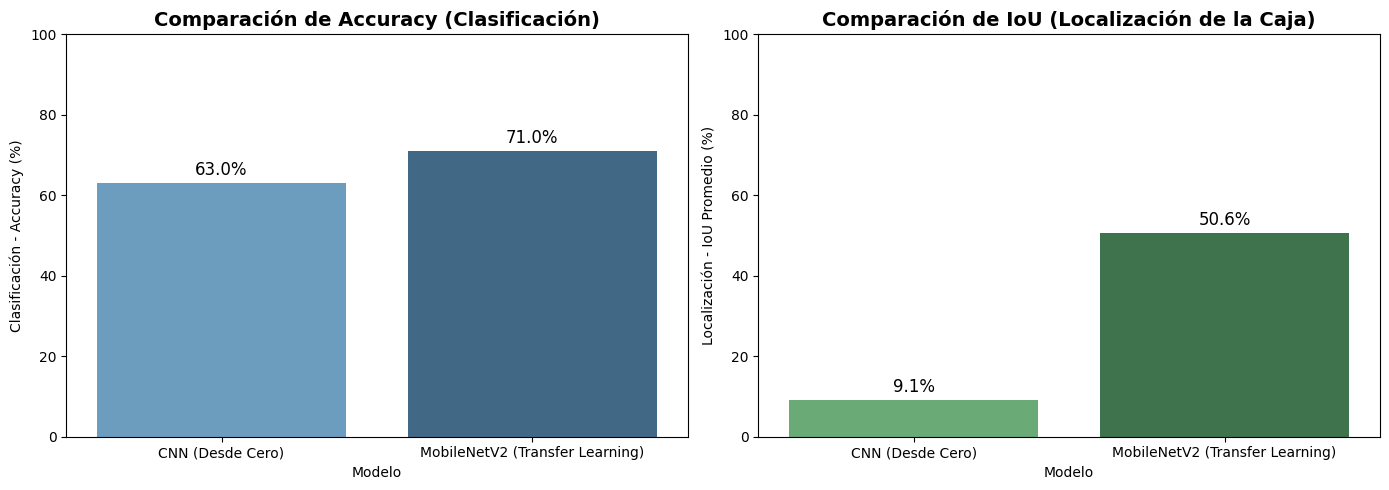


 CURVAS DE ENTRENAMIENTO (MEJOR MODELO: MOBILENETV2)


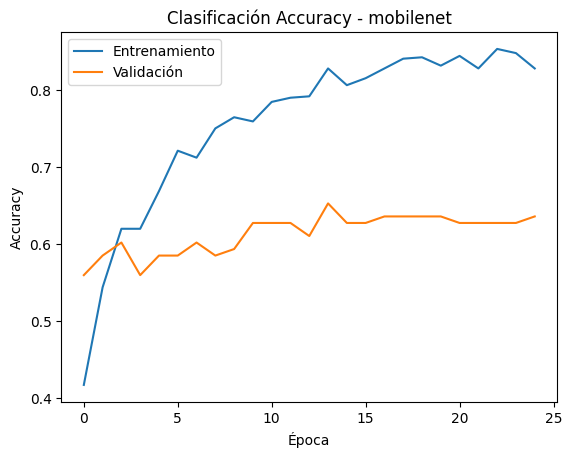

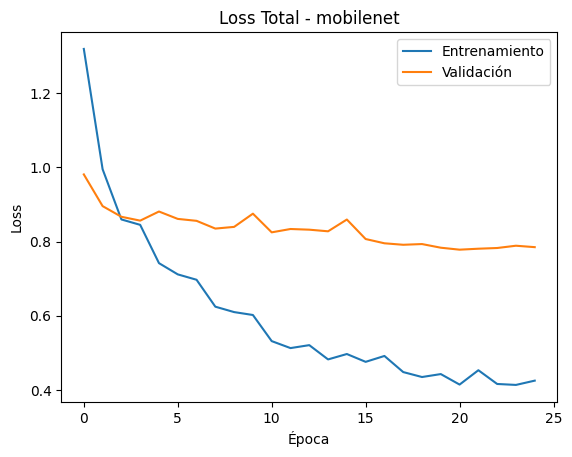

In [13]:
# 7. Demostración Visual de Resultados y Comparación
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Crear una tabla comparativa con los resultados obtenidos
datos = {
    "Modelo": ["CNN (Desde Cero)", "MobileNetV2 (Transfer Learning)"],
    "Clasificación - Accuracy (%)": [63.0, 71.0],
    "Clasificación - F1-Score": [0.54, 0.69],
    "Localización - IoU Promedio (%)": [9.1, 50.6],
    "Cajas Aceptables (IoU > 0.5) (%)": [0.8, 61.0]
}

df_resultados = pd.DataFrame(datos)

print("="*60)
print(" TABLA COMPARATIVA DE RESULTADOS FINALES")
print("="*60)
display(df_resultados)

# 2. Crear gráficas de barras comparativas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Comparación de Accuracy
sns.barplot(x="Modelo", y="Clasificación - Accuracy (%)", data=df_resultados, palette="Blues_d", ax=ax1)
ax1.set_title("Comparación de Accuracy (Clasificación)", fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
for i, v in enumerate(df_resultados["Clasificación - Accuracy (%)"]):
    ax1.text(i, v + 2, f"{v}%", ha='center', fontsize=12)

# Gráfica 2: Comparación de IoU (Cajas)
sns.barplot(x="Modelo", y="Localización - IoU Promedio (%)", data=df_resultados, palette="Greens_d", ax=ax2)
ax2.set_title("Comparación de IoU (Localización de la Caja)", fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
for i, v in enumerate(df_resultados["Localización - IoU Promedio (%)"]):
    ax2.text(i, v + 2, f"{v}%", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Mostrar las curvas de entrenamiento de MobileNetV2 (El mejor modelo)
from IPython.display import Image, display
print("\n" + "="*60)
print(" CURVAS DE ENTRENAMIENTO (MEJOR MODELO: MOBILENETV2)")
print("="*60)
try:
    display(Image(filename='/content/clasificacion-crecimiento-plantas/codigo/resultados/accuracy_mobilenet.png', width=500))
    display(Image(filename='/content/clasificacion-crecimiento-plantas/codigo/resultados/loss_mobilenet.png', width=500))
except FileNotFoundError:
    print("Las gráficas de entrenamiento no se encontraron. Asegúrate de haber corrido las celdas anteriores.")

/content/clasificacion-crecimiento-plantas/codigo
Generando predicción visual...
2026-08-11 04:32:45.521122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-11 04:32:49.706963: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1786422769.708494   28267 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-08-11 04:32:54.390459: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d6ef8003060 initialized for platform CUDA (this does not guarantee tha

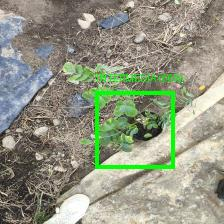

In [14]:
# 8. Generar ejemplos visuales para el documento de Word
%cd /content/clasificacion-crecimiento-plantas/codigo

# Aquí ponemos una imagen cualquiera del set de pruebas (reemplaza la ruta con la tuya)
ruta_ejemplo = "/content/clasificacion-crecimiento-plantas/dataset/test/images/IMG_20260808_155830_jpg.rf.5ae69fbb33751178da509ec7cf0676c4.jpg"

print("Generando predicción visual...")
!python predecir.py --modelo modelos/modelo_mobilenet.keras --imagen {ruta_ejemplo} --dataset_dir ../dataset

from IPython.display import Image, display
# Esto mostrará la imagen pintada directamente aquí en Colab
display(Image(filename=f"resultados/prediccion_{ruta_ejemplo.split('/')[-1]}", width=400))

/content/clasificacion-crecimiento-plantas/codigo
Generando predicción visual...
2026-08-11 04:38:52.160584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-11 04:38:56.314193: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1786423136.315714   29951 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-08-11 04:39:00.838123: I external/local_xla/xla/service/service.cc:163] XLA service 0x7850bc004630 initialized for platform CUDA (this does not guarantee tha

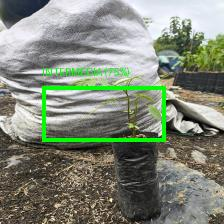

In [16]:
# 8. Generar ejemplos visuales para el documento de Word
%cd /content/clasificacion-crecimiento-plantas/codigo

# Aquí ponemos una imagen cualquiera del set de pruebas (reemplaza la ruta con la tuya)
ruta_ejemplo = "/content/clasificacion-crecimiento-plantas/dataset/test/images/IMG_20260808_151747_jpg.rf.8d3689cbefab1276177ad1dd1da9c418.jpg"

print("Generando predicción visual...")
!python predecir.py --modelo modelos/modelo_mobilenet.keras --imagen {ruta_ejemplo} --dataset_dir ../dataset

from IPython.display import Image, display
# Esto mostrará la imagen pintada directamente aquí en Colab
display(Image(filename=f"resultados/prediccion_{ruta_ejemplo.split('/')[-1]}", width=400))

/content/clasificacion-crecimiento-plantas/codigo
Generando predicción visual...
2026-08-11 04:40:28.257850: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-11 04:40:33.044278: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1786423233.045832   30426 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-08-11 04:40:36.525616: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a091c0044d0 initialized for platform CUDA (this does not guarantee tha

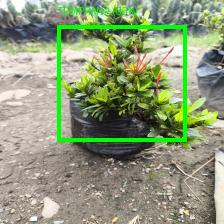

In [17]:
# 8. Generar ejemplos visuales para el documento de Word
%cd /content/clasificacion-crecimiento-plantas/codigo

# Aquí ponemos una imagen cualquiera del set de pruebas (reemplaza la ruta con la tuya)
ruta_ejemplo = "/content/clasificacion-crecimiento-plantas/dataset/test/images/IMG_20260808_150044_jpg.rf.d3ed25c5cd44793cf964983257236dcd.jpg"

print("Generando predicción visual...")
!python predecir.py --modelo modelos/modelo_mobilenet.keras --imagen {ruta_ejemplo} --dataset_dir ../dataset

from IPython.display import Image, display
# Esto mostrará la imagen pintada directamente aquí en Colab
display(Image(filename=f"resultados/prediccion_{ruta_ejemplo.split('/')[-1]}", width=400))

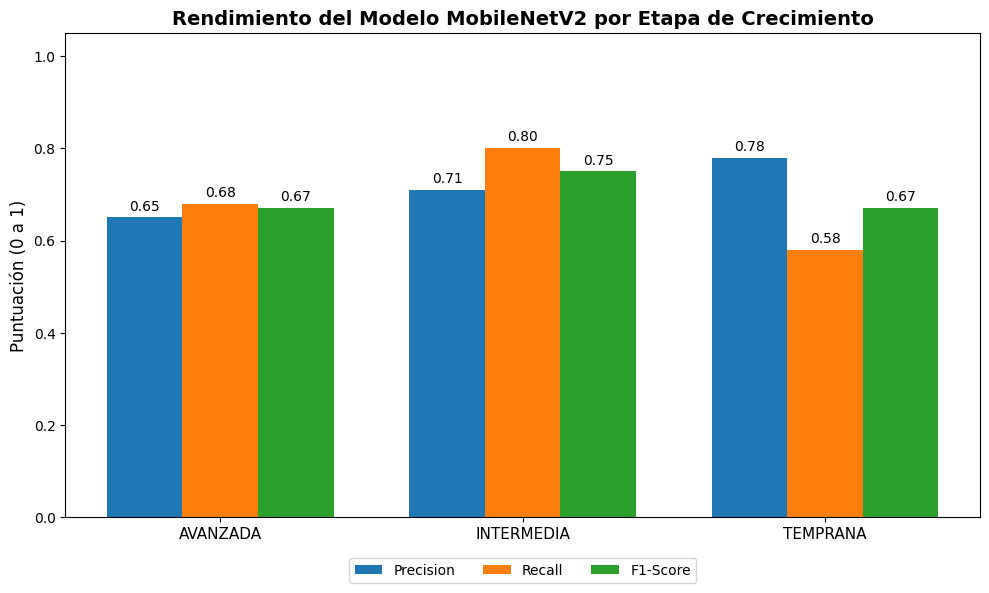

In [18]:
# 9. Gráfica de Métricas por Clase (MobileNetV2)
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de tu último reporte de clasificación
clases = ['AVANZADA', 'INTERMEDIA', 'TEMPRANA']
precision = [0.65, 0.71, 0.78]
recall = [0.68, 0.80, 0.58]
f1_score = [0.67, 0.75, 0.67]

x = np.arange(len(clases))
width = 0.25  # ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#1f77b4')
rects2 = ax.bar(x, recall, width, label='Recall', color='#ff7f0e')
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='#2ca02c')

ax.set_ylabel('Puntuación (0 a 1)', fontsize=12)
ax.set_title('Rendimiento del Modelo MobileNetV2 por Etapa de Crecimiento', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases, fontsize=11)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set_ylim(0, 1.05)

# Añadir los números encima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()